# Phase 3/3 Evaluation


In [4]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import os
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1" # evita il warning

import numpy as np
import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt

import sys
root = Path.cwd().resolve()
if not (root / "src").exists():
    root = root.parent
if not (root / "src").exists():
    raise FileNotFoundError(f"Could not find src package in {root} or its parent")
sys.path.insert(0, str(root))

from src.data import make_loaders
from src.model import load_checkpoint
from src.metrics import regression_metrics

ModuleNotFoundError: No module named 'src'

## 3.1 Load the best model

In [ ]:
loaders, scaler = make_loaders()
ckpts = sorted(Path("../data/checkpoints").glob('*.pt'))

# Train/valid loss of every config, read from each checkpoint's history (no test inference here).
models, rows = {}, []
for p in ckpts:
    m, ck = load_checkpoint(p)
    models[ck['config']['name']] = m
    rows.append(
        {'config': ck['config']['name'],
         'train_loss': ck['train_loss_history'][-1],
         'val_loss': ck['val_loss'],
         'train_hist': ck['train_loss_history'],
         'val_hist': ck['val_loss_history'],}
    )
leaderboard = pd.DataFrame(rows).sort_values('val_loss').reset_index(drop=True)

## 3.2 Comparison among models

In [ ]:
leaderboard[["config","train_loss","val_loss"]]

,config,train_loss,val_loss
0,adam,0.231206,0.240049
1,baseline,0.279857,0.282901
2,high_dropout,0.567921,0.467915
3,shallow,0.679109,0.669057


In [ ]:
best_conf = list(filter(lambda x: x["config"]=="adam", rows))[0]
best_models = models["adam"]
del rows, models

## 3.3 Performance on train-valid-test (best model)

In [ ]:
preds = {}
for split, ld in loaders.items():
    y_true, y_pred, gender = best_models.predict_group(ld, scaler)
    preds[split] = {'y_true': y_true, 'y_pred': y_pred, 'gender': gender}

results = {s: regression_metrics(p['y_true'], p['y_pred']) for s, p in preds.items()}
pd.DataFrame(results).T[["MAE", "RMSE", "R2", "Pearson_r"]].round(3)

,MAE,RMSE,R2,Pearson_r
train,8.679,11.511,0.922,0.967
valid,9.886,13.766,0.899,0.956
test,8.150,10.703,0.926,0.968


## 3.2 Loss history (best model)

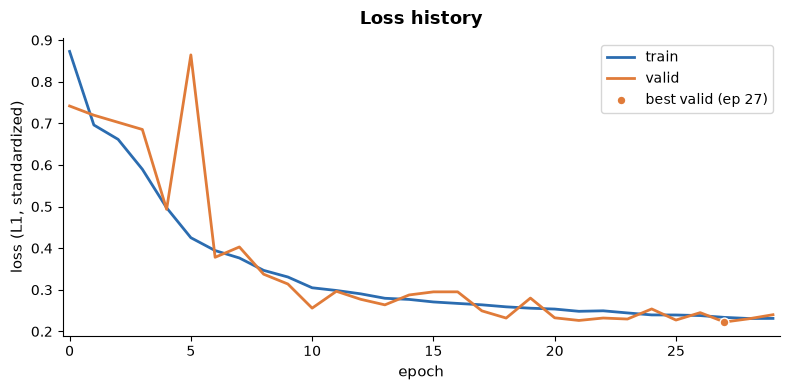

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(best_conf['train_hist'], label='train', color='#2b6cb0', lw=2)
ax.plot(best_conf['val_hist'],   label='valid', color='#e07b39', lw=2)

best_ep = int(np.argmin(best_conf['val_hist']))
ax.scatter(best_ep, best_conf['val_hist'][best_ep], color='#e07b39',
           zorder=5, s=40, ec='white', label=f'best valid (ep {best_ep})')

ax.set_xlabel('epoch', fontsize=11)
ax.set_ylabel('loss (L1, standardized)', fontsize=11)
ax.set_title('Loss history', fontsize=13, fontweight='bold', pad=10)
ax.legend(frameon=True, fontsize=10)
ax.margins(x=0.01)
for s in ('top', 'right'): ax.spines[s].set_visible(False)

fig.tight_layout()
plt.show()

## 4 · Predicted vs. True bone age

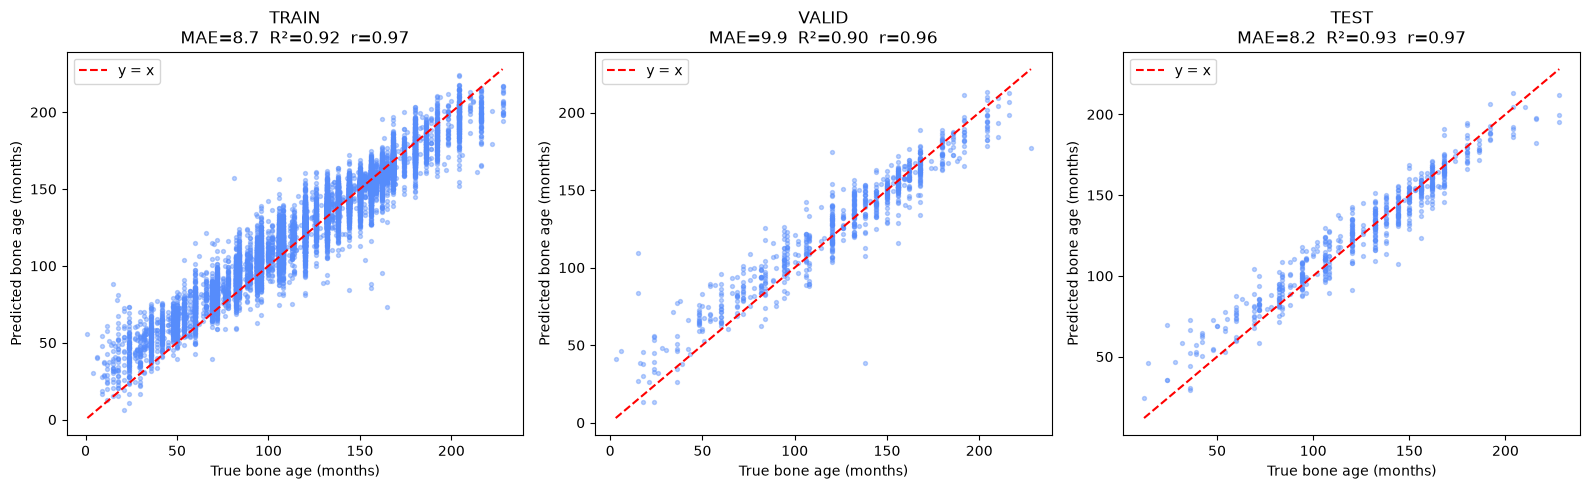

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, split in zip(axes, ['train', 'valid', 'test']):
    y_true, y_pred = preds[split]['y_true'], preds[split]['y_pred']
    lo = float(min(np.min(y_true), np.min(y_pred)))
    hi = float(max(np.max(y_true), np.max(y_pred)))
    ax.scatter(y_true, y_pred, s=8, alpha=0.4)
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="y = x")
    m = regression_metrics(y_true, y_pred)
    ax.set_title(f"{split.upper()}\nMAE={m['MAE']:.1f}  R²={m['R2']:.2f}  r={m['Pearson_r']:.2f}")
    ax.set_xlabel("True bone age (months)")
    ax.set_ylabel("Predicted bone age (months)")
    ax.legend()
plt.tight_layout(); plt.show()

Residuals should be centered at 0 with no trend vs. true age. A downward slope in *residual vs age* (over-predict young, under-predict old) is the classic regression-to-the-mean signature. The gender boxplot checks for systematic bias toward one gender.

## 6 · Error by age group

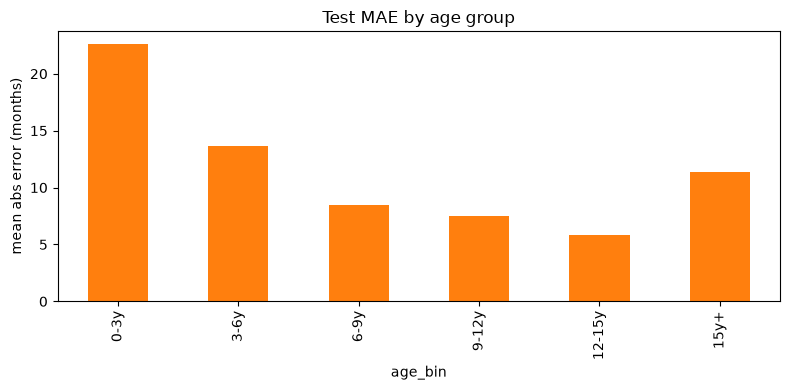

In [ ]:
p = preds['test']
tbl = pd.DataFrame({'true': p['y_true'], 'abs_err': np.abs(p['y_pred'] - p['y_true'])})

tbl['age_bin'] = pd.cut(
    tbl['true'],
    bins=[0,36,72,108,144,180,240],
    labels=['0-3y','3-6y','6-9y','9-12y','12-15y','15y+']
)
by_bin = tbl.groupby('age_bin', observed=True)['abs_err'].mean()

ax = by_bin.plot(kind='bar', figsize=(8,4), color='tab:orange')
ax.set_ylabel('mean abs error (months)'); ax.set_title('Test MAE by age group'); plt.tight_layout(); plt.show()